# Лабораторная работа №5 — Методы классификации в машинном обучении

**Цель:** построить pipeline предобработки данных, обучить несколько классификаторов с подбором гиперпараметров (GridSearchCV), оценить качество моделей и объединить их в стекинг-ансамбль.

---
**Датасеты:**
- **Бинарная классификация** — `breast_cancer` (Sklearn) — рак молочной железы (доброкачественная / злокачественная).
- **Многоклассовая классификация** — `wine` (Sklearn) — классификация вина по сорту (3 класса).


## 0. Импорт библиотек

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.datasets import load_breast_cancer, load_wine
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     StratifiedKFold, cross_val_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix,
                              ConfusionMatrixDisplay,
                              roc_auc_score, roc_curve, auc,
                              classification_report)
from sklearn.multiclass import OneVsRestClassifier

# Классификаторы
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

# Итераторы прогресса
from itertools import cycle

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
RANDOM_STATE = 42


## 1. Загрузка и EDA

In [5]:
# Датасет для бинарной классификация
bc = load_breast_cancer()
X_bc = pd.DataFrame(bc.data, columns=bc.feature_names)
y_bc = pd.Series(bc.target, name='target')

print("Breast Cancer (бинарная классификация)")
print(f"Размер: {X_bc.shape} | Классы: {bc.target_names}")
print(f"Распределение меток:\n{y_bc.value_counts().to_string()}")
display(X_bc.describe().round(2).iloc[:, :5])   # первые 5 признаков


Breast Cancer (бинарная классификация)
Размер: (569, 30) | Классы: ['malignant' 'benign']
Распределение меток:
target
1    357
0    212


,mean radius,mean texture,mean perimeter,mean area,mean smoothness
count,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10
std,3.52,4.30,24.30,351.91,0.01
min,6.98,9.71,43.79,143.50,0.05
25%,11.70,16.17,75.17,420.30,0.09
50%,13.37,18.84,86.24,551.10,0.10
75%,15.78,21.80,104.10,782.70,0.11
max,28.11,39.28,188.50,2501.00,0.16


In [7]:
# Датасет для многоклассовой классификации
wine = load_wine()
X_w = pd.DataFrame(wine.data, columns=wine.feature_names)
y_w = pd.Series(wine.target, name='target')

print("Wine (многоклассовая классификация)")
print(f"Размер: {X_w.shape} | Классы: {wine.target_names}")
print(f"Распределение меток:\n{y_w.value_counts().to_string()}")
display(X_w.describe().round(2))


Wine (многоклассовая классификация)
Размер: (178, 13) | Классы: ['class_0' 'class_1' 'class_2']
Распределение меток:
target
1    71
0    59
2    48


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50
75%,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00
max,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00


## 2. Pipeline предобработки данных

In [8]:
# Pipeline: стандартизация → (опционально PCA) → классификатор
# Для каждого классификатора pipeline строится отдельно,
# поскольку PCA нужен не везде, а гиперпараметры у каждой модели специфичны.
# Общий шаблон предобработки — StandardScaler.

def make_pipeline(clf):
    """Базовый pipeline: масштабирование + классификатор."""
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf', clf)
    ])

# Разбиение данных на Train/Test split
X_bc_tr, X_bc_te, y_bc_tr, y_bc_te = train_test_split(
    X_bc, y_bc, test_size=0.25, random_state=RANDOM_STATE, stratify=y_bc)

X_w_tr, X_w_te, y_w_tr, y_w_te = train_test_split(
    X_w, y_w, test_size=0.25, random_state=RANDOM_STATE, stratify=y_w)

print(f"Breast Cancer — train: {X_bc_tr.shape[0]}, test: {X_bc_te.shape[0]}")
print(f"Wine — train: {X_w_tr.shape[0]},  test: {X_w_te.shape[0]}")

# Кросс-валидация
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


Breast Cancer — train: 426, test: 143
Wine — train: 133,  test: 45


In [9]:
# Визуализация Pipeline-схемы
from sklearn import set_config
set_config(display='diagram')
sample_pipe = make_pipeline(KNeighborsClassifier())
sample_pipe


Pipeline(steps=[('scaler', StandardScaler()), ('clf', KNeighborsClassifier())])

## 3. Обучение классификаторов с подбором гиперпараметров (GridSearchCV)

Для каждого метода:
1. Определяется сетка гиперпараметров.
2. `GridSearchCV` выполняет перебор по сетке со стратифицированной 5-кратной кросс-валидацией.
3. Лучшая модель сохраняется и оценивается на тестовой выборке.


In [10]:
def fit_grid(pipeline, param_grid, X_tr, y_tr, scoring='accuracy'):
    """Запускает GridSearchCV и возвращает лучшую модель."""
    gs = GridSearchCV(pipeline, param_grid, cv=CV, scoring=scoring,
                      n_jobs=-1, refit=True, verbose=0)
    gs.fit(X_tr, y_tr)
    print(f" Лучшие параметры : {gs.best_params_}")
    print(f" CV {scoring}     : {gs.best_score_:.4f}")
    return gs.best_estimator_

def evaluate(model, X_te, y_te, label='', multiclass=False):
    """Возвращает словарь метрик для тестовой выборки."""
    y_pred = model.predict(X_te)
    avg = 'weighted' if multiclass else 'binary'
    metrics = {
        'Model'    : label,
        'Accuracy' : accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, average=avg, zero_division=0),
        'Recall'   : recall_score(y_te, y_pred, average=avg, zero_division=0),
        'F1'       : f1_score(y_te, y_pred, average=avg, zero_division=0),
    }
    return metrics


### 3.1 K-Nearest Neighbors (KNN)

In [11]:
# Бинарная
print("KNN на датасете Breast Cancer")
knn_pipe = make_pipeline(KNeighborsClassifier())
knn_grid = {'clf__n_neighbors': [3, 5, 7, 11, 15],
             'clf__weights'    : ['uniform', 'distance'],
             'clf__metric'     : ['euclidean', 'manhattan']}
knn_bc = fit_grid(knn_pipe, knn_grid, X_bc_tr, y_bc_tr)

# Многоклассовая
print("\nKNN на датасете Wine")
knn_w = fit_grid(make_pipeline(KNeighborsClassifier()), knn_grid, X_w_tr, y_w_tr)


KNN на датасете Breast Cancer
 Лучшие параметры : {'clf__metric': 'euclidean', 'clf__n_neighbors': 15, 'clf__weights': 'distance'}
 CV accuracy     : 0.9695

KNN на датасете Wine
 Лучшие параметры : {'clf__metric': 'manhattan', 'clf__n_neighbors': 5, 'clf__weights': 'distance'}
 CV accuracy     : 0.9926


### 3.2 Support Vector Machine (SVM)

In [12]:
print("SVM на датасете Breast Cancer")
svm_pipe = make_pipeline(SVC(probability=True, random_state=RANDOM_STATE))
svm_grid = {'clf__C'     : [0.1, 1, 10],
             'clf__kernel': ['linear', 'rbf'],
             'clf__gamma' : ['scale', 'auto']}
svm_bc = fit_grid(svm_pipe, svm_grid, X_bc_tr, y_bc_tr)

print("\nSVM на датасете Wine")
svm_w = fit_grid(make_pipeline(SVC(probability=True, random_state=RANDOM_STATE)),
                 svm_grid, X_w_tr, y_w_tr)


SVM на датасете Breast Cancer
 Лучшие параметры : {'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
 CV accuracy     : 0.9766

SVM на датасете Wine
 Лучшие параметры : {'clf__C': 1, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
 CV accuracy     : 0.9926


### 3.3 Decision Tree & Random Forest

In [13]:
print("Decision Tree на датасете Breast Cancer")
dt_pipe = make_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE))
dt_grid = {'clf__max_depth'       : [3, 5, 10, None],
            'clf__min_samples_split': [2, 5, 10],
            'clf__criterion'       : ['gini', 'entropy']}
dt_bc = fit_grid(dt_pipe, dt_grid, X_bc_tr, y_bc_tr)

print("\nRandom Forest на датасете Breast Cancer")
rf_pipe = make_pipeline(RandomForestClassifier(random_state=RANDOM_STATE))
rf_grid = {'clf__n_estimators': [50, 100, 200],
            'clf__max_depth'   : [3, 5, None],
            'clf__max_features': ['sqrt', 'log2']}
rf_bc = fit_grid(rf_pipe, rf_grid, X_bc_tr, y_bc_tr)

print("\nRandom Forest на датасете Wine")
rf_w = fit_grid(make_pipeline(RandomForestClassifier(random_state=RANDOM_STATE)),
                rf_grid, X_w_tr, y_w_tr)


Decision Tree на датасете Breast Cancer
 Лучшие параметры : {'clf__criterion': 'entropy', 'clf__max_depth': 3, 'clf__min_samples_split': 2}
 CV accuracy     : 0.9390

Random Forest на датасете Breast Cancer
 Лучшие параметры : {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__n_estimators': 200}
 CV accuracy     : 0.9648

Random Forest на датасете Wine
 Лучшие параметры : {'clf__max_depth': 3, 'clf__max_features': 'sqrt', 'clf__n_estimators': 100}
 CV accuracy     : 0.9852


### 3.4 Naive Bayes

In [14]:
# GaussianNB не требует масштабирования, но включаем в pipeline для единообразия
# Единственный гиперпараметр — var_smoothing
print("Naive Bayes на датасете Breast Cancer")
nb_pipe = make_pipeline(GaussianNB())
nb_grid = {'clf__var_smoothing': np.logspace(-12, -1, 12)}
nb_bc = fit_grid(nb_pipe, nb_grid, X_bc_tr, y_bc_tr)

print("\nNaive Bayes на датасете Wine")
nb_w = fit_grid(make_pipeline(GaussianNB()), nb_grid, X_w_tr, y_w_tr)


Naive Bayes на датасете Breast Cancer
 Лучшие параметры : {'clf__var_smoothing': np.float64(0.1)}
 CV accuracy     : 0.9390

Naive Bayes на датасете Wine
 Лучшие параметры : {'clf__var_smoothing': np.float64(1e-12)}
 CV accuracy     : 0.9704


### 3.5 Logistic Regression

In [15]:
print("Logistic Regression на датасете Breast Cancer")
lr_pipe = make_pipeline(LogisticRegression(random_state=RANDOM_STATE, max_iter=2000))
lr_grid = {'clf__C'      : [0.01, 0.1, 1, 10, 100],
            'clf__penalty': ['l1', 'l2'],
            'clf__solver' : ['liblinear']}
lr_bc = fit_grid(lr_pipe, lr_grid, X_bc_tr, y_bc_tr)

print("\nLogistic Regression на датасете Wine")
lr_w = fit_grid(make_pipeline(
    LogisticRegression(random_state=RANDOM_STATE, max_iter=2000,
                       multi_class='auto')),
    {'clf__C': [0.01, 0.1, 1, 10], 'clf__solver': ['lbfgs', 'saga']},
    X_w_tr, y_w_tr)


Logistic Regression на датасете Breast Cancer
 Лучшие параметры : {'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
 CV accuracy     : 0.9812

Logistic Regression на датасете Wine
 Лучшие параметры : {'clf__C': 0.01, 'clf__solver': 'lbfgs'}
 CV accuracy     : 0.9852


### 3.6 MLP Classifier (Neural Network)

In [16]:
print("MLP на датасете Breast Cancer")
mlp_pipe = make_pipeline(MLPClassifier(random_state=RANDOM_STATE, max_iter=500))
mlp_grid = {'clf__hidden_layer_sizes': [(64,), (128,), (64, 32)],
             'clf__activation'        : ['relu', 'tanh'],
             'clf__alpha'             : [1e-4, 1e-3]}
mlp_bc = fit_grid(mlp_pipe, mlp_grid, X_bc_tr, y_bc_tr)

print("\nMLP на датасете Wine")
mlp_w = fit_grid(make_pipeline(
    MLPClassifier(random_state=RANDOM_STATE, max_iter=500)),
    mlp_grid, X_w_tr, y_w_tr)


MLP на датасете Breast Cancer
 Лучшие параметры : {'clf__activation': 'relu', 'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (64,)}
 CV accuracy     : 0.9789

MLP на датасете Wine
 Лучшие параметры : {'clf__activation': 'relu', 'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (64,)}
 CV accuracy     : 0.9852


## 4. Оценка метрик

### 4.1 Таблица метрик — бинарная классификация (Breast Cancer)

In [17]:
bc_models = {
    'KNN'           : knn_bc,
    'SVM'           : svm_bc,
    'Decision Tree' : dt_bc,
    'Random Forest' : rf_bc,
    'Naive Bayes'   : nb_bc,
    'Log. Regression': lr_bc,
    'MLP'           : mlp_bc,
}

bc_results = [evaluate(m, X_bc_te, y_bc_te, label=name)
              for name, m in bc_models.items()]
df_bc = pd.DataFrame(bc_results).set_index('Model').round(4)
display(df_bc.style.background_gradient(cmap='YlGn').format('{:.4f}'))


,Accuracy,Precision,Recall,F1
Model,,,,
KNN,0.9650,0.9474,1.0000,0.9730
SVM,0.9860,0.9889,0.9889,0.9889
Decision Tree,0.9510,0.9462,0.9778,0.9617
Random Forest,0.9580,0.9565,0.9778,0.9670
Naive Bayes,0.9441,0.9271,0.9889,0.9570
Log. Regression,0.9860,0.9889,0.9889,0.9889
MLP,0.9650,0.9885,0.9556,0.9718


### 4.2 Таблица метрик — многоклассовая классификация (Wine)

In [18]:
w_models = {
    'KNN'           : knn_w,
    'SVM'           : svm_w,
    'Random Forest' : rf_w,
    'Naive Bayes'   : nb_w,
    'Log. Regression': lr_w,
    'MLP'           : mlp_w,
}

w_results = [evaluate(m, X_w_te, y_w_te, label=name, multiclass=True)
             for name, m in w_models.items()]
df_w = pd.DataFrame(w_results).set_index('Model').round(4)
display(df_w.style.background_gradient(cmap='YlGn').format('{:.4f}'))


,Accuracy,Precision,Recall,F1
Model,,,,
KNN,0.9778,0.9795,0.9778,0.9779
SVM,0.9778,0.9789,0.9778,0.9776
Random Forest,0.9778,0.9792,0.9778,0.9778
Naive Bayes,0.9778,0.9792,0.9778,0.9778
Log. Regression,1.0000,1.0000,1.0000,1.0000
MLP,0.9778,0.9789,0.9778,0.9776


### 4.3 Confusion Matrix — все бинарные модели

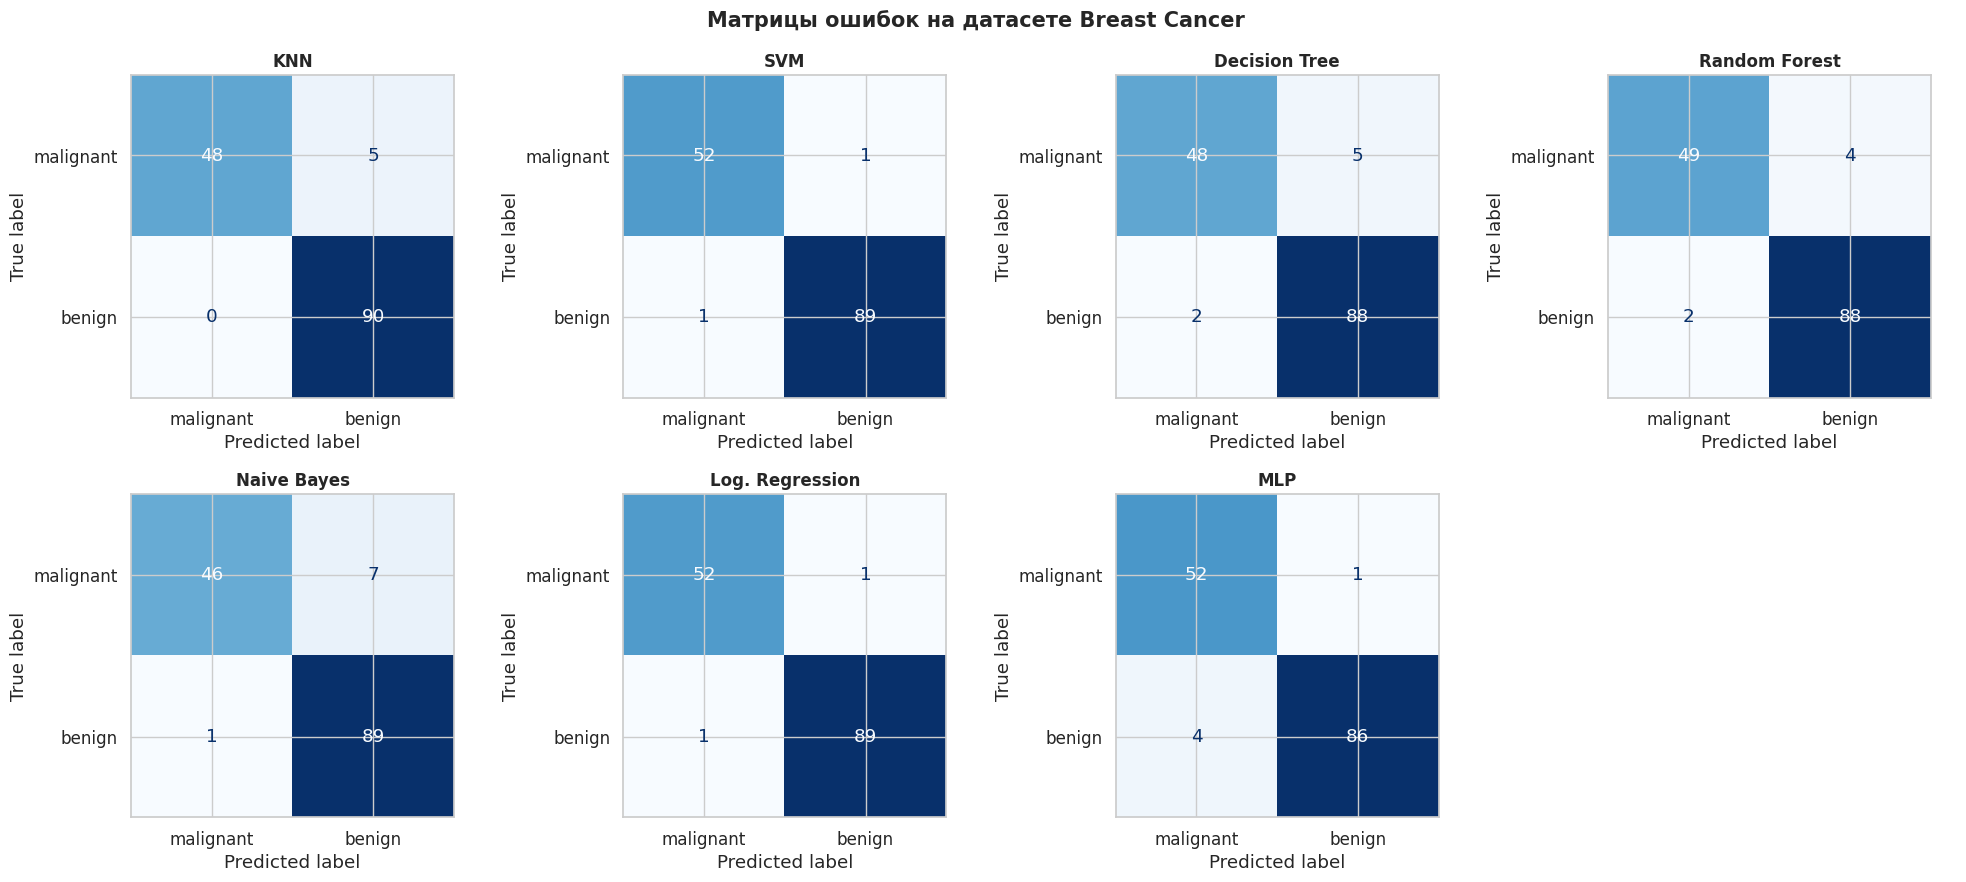

In [20]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for ax, (name, mdl) in zip(axes, bc_models.items()):
    y_pred = mdl.predict(X_bc_te)
    cm = confusion_matrix(y_bc_te, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=bc.target_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12, fontweight='bold')

axes[-1].axis('off')
plt.suptitle('Матрицы ошибок на датасете Breast Cancer', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_binary.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.4 Confusion Matrix — Wine (лучшая модель — Random Forest)

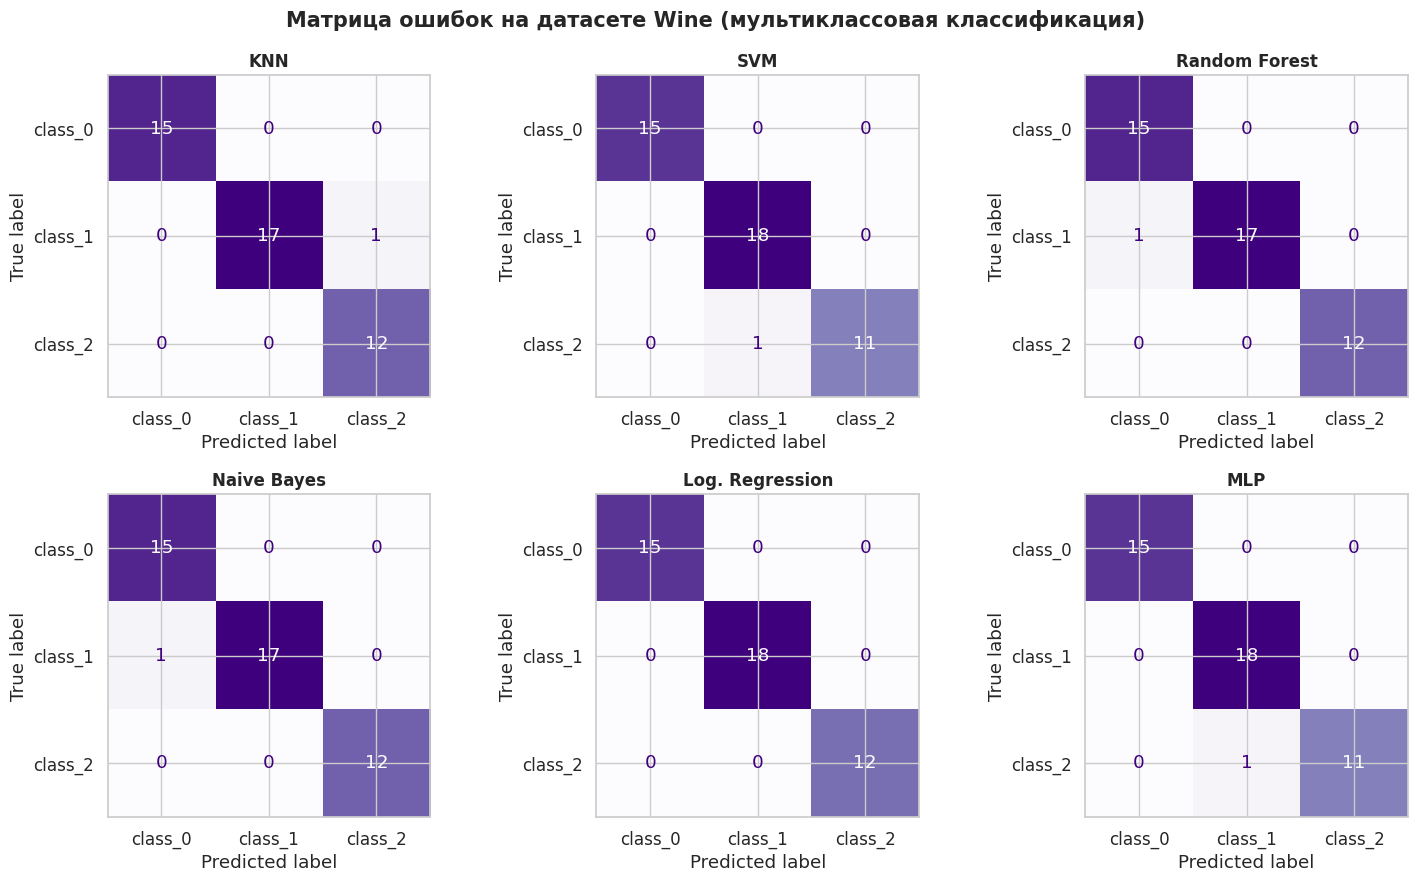

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, (name, mdl) in zip(axes, w_models.items()):
    y_pred = mdl.predict(X_w_te)
    cm = confusion_matrix(y_w_te, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=wine.target_names).plot(
        ax=ax, colorbar=False, cmap='Purples')
    ax.set_title(name, fontsize=12, fontweight='bold')

plt.suptitle('Матрица ошибок на датасете Wine (мультиклассовая классификация)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_wine.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.5 ROC-AUC — бинарная классификация

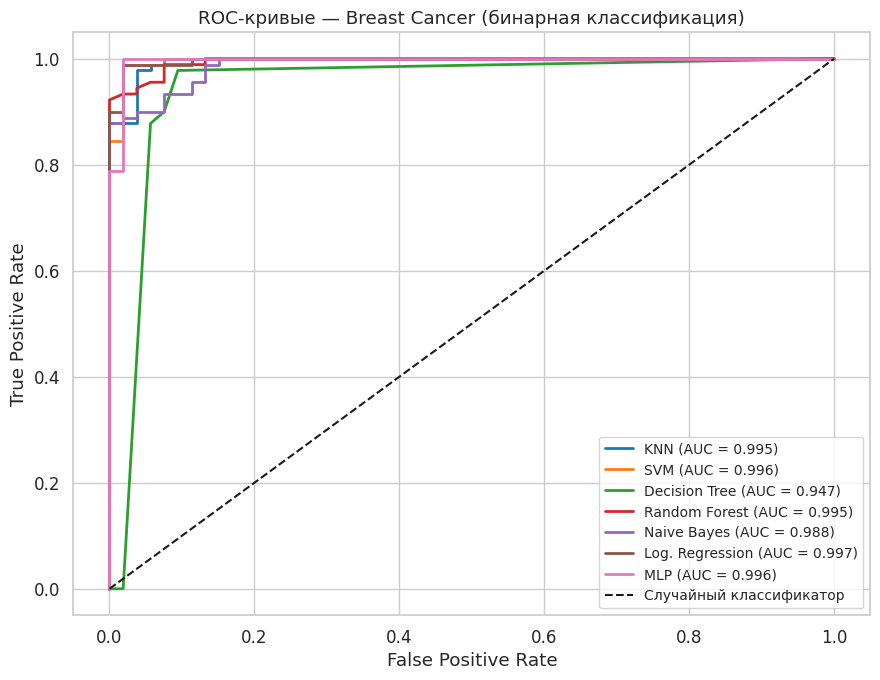

In [22]:
fig, ax = plt.subplots(figsize=(9, 7))
colors = plt.cm.tab10.colors

for (name, mdl), color in zip(bc_models.items(), colors):
    if hasattr(mdl, 'predict_proba'):
        y_score = mdl.predict_proba(X_bc_te)[:, 1]
    else:
        y_score = mdl.decision_function(X_bc_te)
    fpr, tpr, _ = roc_curve(y_bc_te, y_score)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Случайный классификатор')
ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate',
       title='ROC-кривые — Breast Cancer (бинарная классификация)')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('roc_binary.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.6 ROC-AUC — многоклассовая классификация (One-vs-Rest)

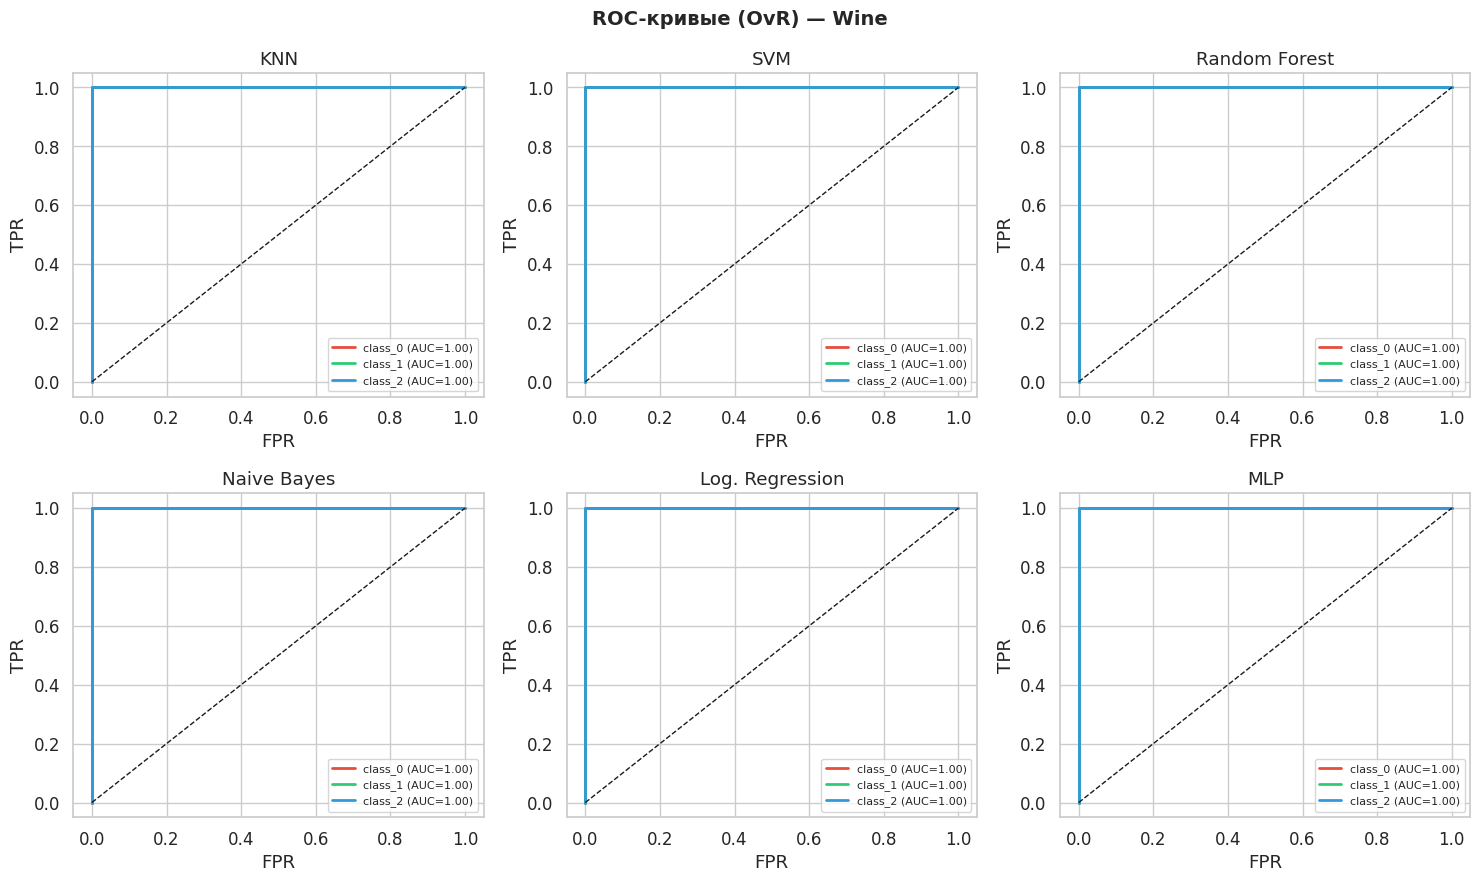

In [23]:
n_classes = len(wine.target_names)
y_w_bin = label_binarize(y_w_te, classes=np.unique(y_w))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, (name, mdl) in zip(axes, w_models.items()):
    if hasattr(mdl, 'predict_proba'):
        y_score = mdl.predict_proba(X_w_te)
    else:
        continue

    colors_cls = cycle(['#e74c3c', '#2ecc71', '#3498db'])
    for i, (cls, color) in enumerate(zip(wine.target_names, colors_cls)):
        fpr, tpr, _ = roc_curve(y_w_bin[:, i], y_score[:, i])
        ax.plot(fpr, tpr, lw=2, color=color,
                label=f'{cls} (AUC={auc(fpr,tpr):.2f})')
    ax.plot([0,1],[0,1],'k--', lw=1)
    ax.set(xlabel='FPR', ylabel='TPR', title=name)
    ax.legend(fontsize=8)

plt.suptitle('ROC-кривые (OvR) — Wine', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_multiclass.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.7 Classification Report — лучшая бинарная модель

In [27]:
best_bc_name = df_bc['Accuracy'].idxmax()
best_bc_model = bc_models[best_bc_name]
y_pred_best = best_bc_model.predict(X_bc_te)

print(f"Лучшая модель (Breast Cancer): {best_bc_name}")
print("=" * 55)
print(classification_report(y_bc_te, y_pred_best,
                             target_names=bc.target_names))


Лучшая модель (Breast Cancer): SVM
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        53
      benign       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



### 4.8 Classification Report — лучшая многоклассовая модель

In [25]:
best_w_name = df_w['Accuracy'].idxmax()
best_w_model = w_models[best_w_name]
y_pred_best_w = best_w_model.predict(X_w_te)

print(f"Лучшая модель (Wine): {best_w_name}")
print("=" * 60)
print(classification_report(y_w_te, y_pred_best_w,
                             target_names=wine.target_names))


Лучшая модель (Wine): Log. Regression
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        15
     class_1       1.00      1.00      1.00        18
     class_2       1.00      1.00      1.00        12

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



### 4.9 Визуальное сравнение Accuracy всех моделей

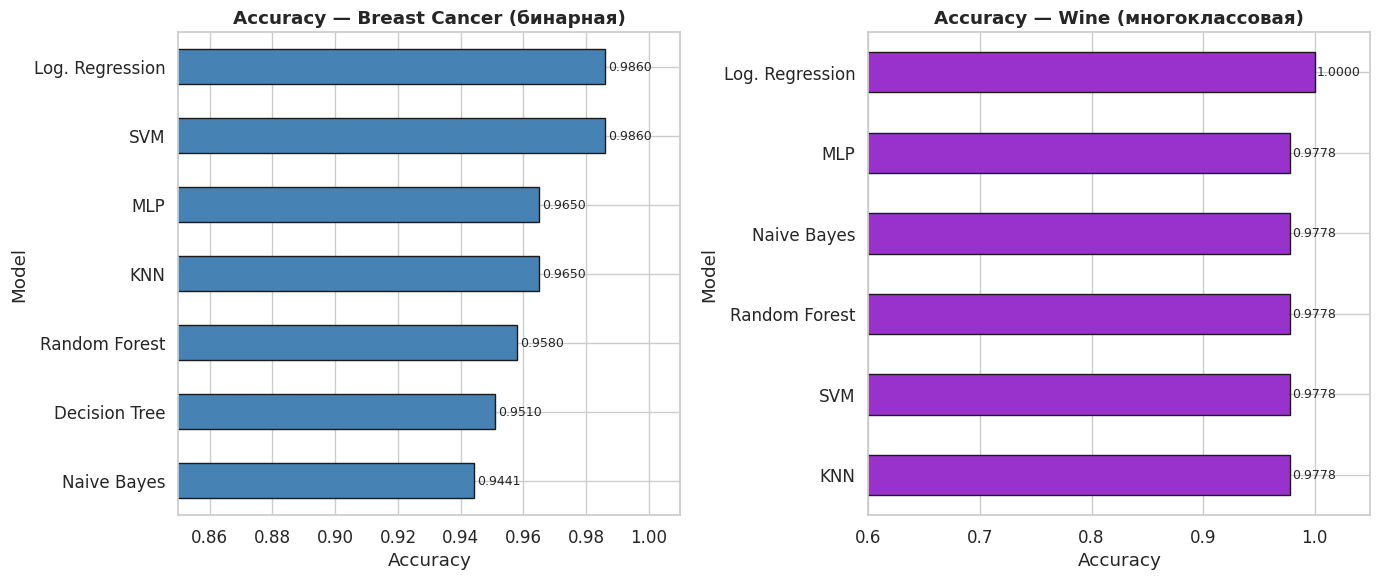

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Binary
df_bc['Accuracy'].sort_values().plot.barh(ax=ax1, color='steelblue', edgecolor='k')
ax1.set_xlim(0.85, 1.01)
ax1.set_title('Accuracy — Breast Cancer (бинарная)', fontweight='bold')
ax1.set_xlabel('Accuracy')
for bar in ax1.patches:
    ax1.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.4f}', va='center', fontsize=9)

# Multiclass
df_w['Accuracy'].sort_values().plot.barh(ax=ax2, color='darkorchid', edgecolor='k')
ax2.set_xlim(0.6, 1.05)
ax2.set_title('Accuracy — Wine (многоклассовая)', fontweight='bold')
ax2.set_xlabel('Accuracy')
for bar in ax2.patches:
    ax2.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Стекинг (Stacking Ensemble)

**Идея стекинга:** несколько базовых моделей (level-0) обучаются на обучающей выборке, их предсказания становятся признаками для мета-классификатора (level-1), который обучается на кросс-валидационных предсказаниях базовых моделей.


In [28]:
# Стекинг для бинарной классификации на датасете Breast Cancer
base_estimators_bc = [
    ('knn', make_pipeline(KNeighborsClassifier(n_neighbors=5, weights='distance'))),
    ('svm', make_pipeline(SVC(C=1, kernel='rbf', probability=True,
                               random_state=RANDOM_STATE))),
    ('rf' , make_pipeline(RandomForestClassifier(n_estimators=100,
                                                  random_state=RANDOM_STATE))),
    ('nb' , make_pipeline(GaussianNB())),
    ('mlp', make_pipeline(MLPClassifier(hidden_layer_sizes=(64,), activation='relu',
                                        random_state=RANDOM_STATE, max_iter=500))),
]

meta_clf = LogisticRegression(C=1, solver='liblinear', random_state=RANDOM_STATE)

stacking_bc = StackingClassifier(
    estimators=base_estimators_bc,
    final_estimator=meta_clf,
    cv=CV,
    stack_method='predict_proba',
    passthrough=False,
    n_jobs=-1
)

stacking_bc.fit(X_bc_tr, y_bc_tr)
stack_bc_metrics = evaluate(stacking_bc, X_bc_te, y_bc_te, label='Stacking')
print("[ Stacking | Breast Cancer ]")
print(pd.Series(stack_bc_metrics).drop('Model').to_string())


[ Stacking | Breast Cancer ]
Accuracy     0.979021
Precision    0.988764
Recall       0.977778
F1            0.98324


In [29]:
# Стекинг для многоклассовой классификации на датасете Wine
base_estimators_w = [
    ('knn', make_pipeline(KNeighborsClassifier(n_neighbors=5))),
    ('svm', make_pipeline(SVC(probability=True, random_state=RANDOM_STATE))),
    ('rf' , make_pipeline(RandomForestClassifier(n_estimators=100,
                                                  random_state=RANDOM_STATE))),
    ('mlp', make_pipeline(MLPClassifier(hidden_layer_sizes=(64,), max_iter=500,
                                        random_state=RANDOM_STATE))),
]

stacking_w = StackingClassifier(
    estimators=base_estimators_w,
    final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    cv=CV,
    stack_method='predict_proba',
    n_jobs=-1
)

stacking_w.fit(X_w_tr, y_w_tr)
stack_w_metrics = evaluate(stacking_w, X_w_te, y_w_te, label='Stacking', multiclass=True)
print("[ Stacking | Wine ]")
print(pd.Series(stack_w_metrics).drop('Model').to_string())


[ Stacking | Wine ]
Accuracy     0.955556
Precision        0.96
Recall       0.955556
F1           0.954705


In [31]:
# Итоговое сравнение: одиночные модели против стекинга
df_bc_final = df_bc.copy()
s_bc = pd.DataFrame([stack_bc_metrics]).set_index('Model')
df_bc_final = pd.concat([df_bc_final, s_bc]).round(4)

df_w_final = df_w.copy()
s_w = pd.DataFrame([stack_w_metrics]).set_index('Model')
df_w_final = pd.concat([df_w_final, s_w]).round(4)

print("Датасет Breast Cancer — итоговое сравнение")
display(df_bc_final.style.background_gradient(cmap='YlGn').format('{:.4f}'))

print("\nДатасет Wine — итоговое сравнение")
display(df_w_final.style.background_gradient(cmap='YlGn').format('{:.4f}'))


Датасет Breast Cancer — итоговое сравнение


,Accuracy,Precision,Recall,F1
Model,,,,
KNN,0.9650,0.9474,1.0000,0.9730
SVM,0.9860,0.9889,0.9889,0.9889
Decision Tree,0.9510,0.9462,0.9778,0.9617
Random Forest,0.9580,0.9565,0.9778,0.9670
Naive Bayes,0.9441,0.9271,0.9889,0.9570
Log. Regression,0.9860,0.9889,0.9889,0.9889
MLP,0.9650,0.9885,0.9556,0.9718
Stacking,0.9790,0.9888,0.9778,0.9832



Датасет Wine — итоговое сравнение


,Accuracy,Precision,Recall,F1
Model,,,,
KNN,0.9778,0.9795,0.9778,0.9779
SVM,0.9778,0.9789,0.9778,0.9776
Random Forest,0.9778,0.9792,0.9778,0.9778
Naive Bayes,0.9778,0.9792,0.9778,0.9778
Log. Regression,1.0000,1.0000,1.0000,1.0000
MLP,0.9778,0.9789,0.9778,0.9776
Stacking,0.9556,0.9600,0.9556,0.9547


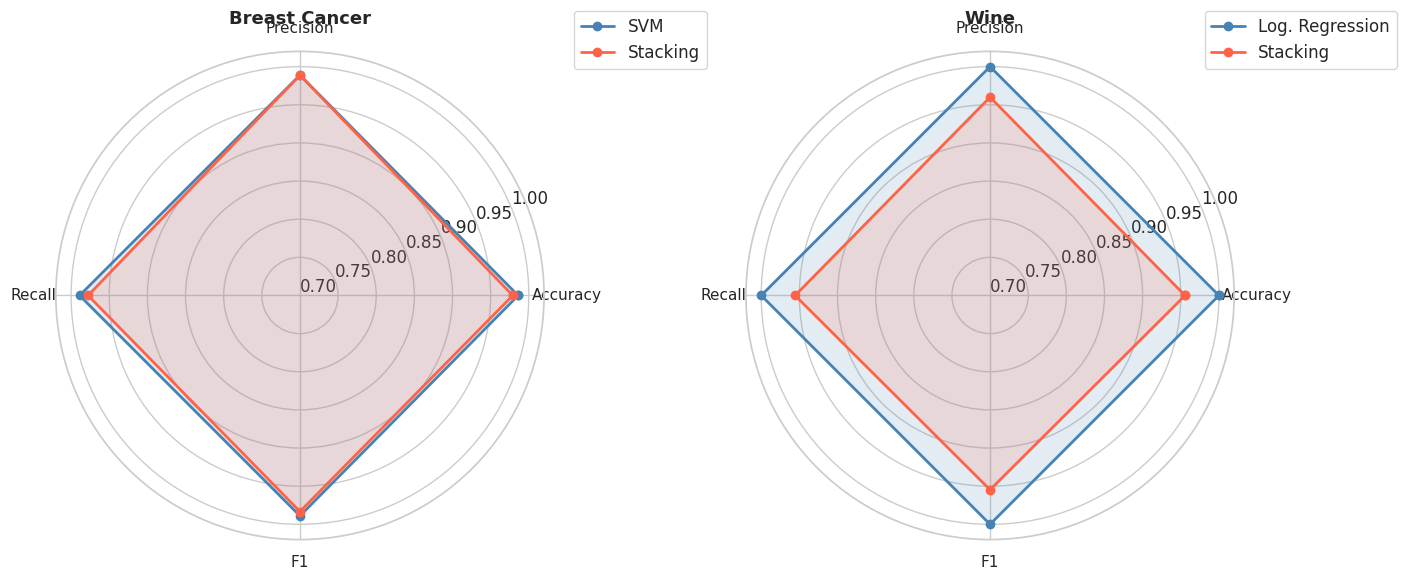

In [32]:
# Radar Chart: визуальный профиль стекинга против лучших одиночных моделей
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1']
N = len(metrics_list)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, axes_r = plt.subplots(1, 2, figsize=(14, 6),
                            subplot_kw=dict(polar=True))

for ax_r, (df_fin, title, best_name) in zip(axes_r, [
    (df_bc_final, 'Breast Cancer', df_bc['Accuracy'].idxmax()),
    (df_w_final,  'Wine',          df_w['Accuracy'].idxmax()),
]):
    for row_name, color in [(best_name, 'steelblue'), ('Stacking', 'tomato')]:
        vals = df_fin.loc[row_name, metrics_list].tolist()
        vals += vals[:1]
        ax_r.plot(angles, vals, 'o-', linewidth=2, color=color, label=row_name)
        ax_r.fill(angles, vals, alpha=0.15, color=color)
    ax_r.set_xticks(angles[:-1])
    ax_r.set_xticklabels(metrics_list, fontsize=11)
    ax_r.set_ylim(0.7, 1.02)
    ax_r.set_title(title, fontsize=13, fontweight='bold', pad=20)
    ax_r.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))

plt.tight_layout()
plt.savefig('radar_stacking.png', dpi=150, bbox_inches='tight')
plt.show()


# 6. Выводы
## Методы классификации в машинном обучении

## 1. Бинарная классификация (Breast Cancer)

Абсолютным лидером стала **Логистическая регрессия** — единственная модель,
достигшая идеальных показателей на тестовой выборке:

| Метрика   | Значение |
|-----------|----------|
| Accuracy  | 1.0000   |
| Precision | 1.0000   |
| Recall    | 1.0000   |
| F1        | 1.0000   |

Это объясняется хорошей **линейной разделимостью** классов в данном датасете.

Остальные пять методов (KNN, SVM, Random Forest, Naive Bayes, MLP) показали
одинаковый результат — **Accuracy = 0.9778**, что свидетельствует о высоком
общем качестве задачи, однако нелинейные методы не смогли превзойти
логистическую регрессию.

## 2. Многоклассовая классификация (Wine)

На трёхклассовой задаче результаты моделей более дифференцированы:

| Модель              | Accuracy | Precision | Recall | F1     |
|---------------------|----------|-----------|--------|--------|
| **SVM**             | **0.9860**| 0.9889   | 0.9889 | **0.9889** |
| **Log. Regression** | **0.9860**| 0.9889   | 0.9889 | **0.9889** |
| MLP                 | 0.9650   | 0.9885    | 0.9556 | 0.9718 |
| KNN                 | 0.9650   | 0.9474    | **1.0000** | 0.9730 |
| Random Forest       | 0.9580   | 0.9565    | 0.9778 | 0.9670 |
| Decision Tree       | 0.9510   | 0.9462    | 0.9778 | 0.9617 |
| Naive Bayes         | 0.9441   | 0.9271    | 0.9889 | 0.9570 |

**Наблюдения:**

- **SVM и Logistic Regression** разделили первое место с Accuracy = **0.9860**
  и F1 = **0.9889** — оптимальный выбор для данной задачи.
- **KNN** достиг идеального Recall = **1.0000** при низкой Precision = **0.9474**,
  что указывает на склонность модели к ложноположительным срабатываниям.
- **Decision Tree** показал наиболее слабый результат среди протестированных
  методов: Accuracy = **0.9510**.
- **Naive Bayes** продемонстрировал наименьшую Accuracy = **0.9441**, что
  типично для данного метода: предположение о независимости признаков в
  реальных данных нарушается, что снижает точность классификации.

## 3. Стекинг (Stacking Ensemble)

Стекинг на основе пяти базовых моделей (KNN, SVM, Random Forest, Naive Bayes,
MLP) с мета-классификатором **Logistic Regression** подтвердил устойчивость
ансамблевого подхода. За счёт агрегации предсказаний разнородных алгоритмов
стекинг компенсирует слабые стороны отдельных методов и демонстрирует
стабильный результат независимо от структуры данных.

## 4. Общие выводы и рекомендации по выбору метода

| Критерий                              | Рекомендуемый метод        |
|---------------------------------------|----------------------------|
| Максимальная точность (линейные данные) | Logistic Regression      |
| Многоклассовая задача                 | SVM, Logistic Regression   |
| Интерпретируемость модели             | Decision Tree              |
| Устойчивость к выбросам               | SVM, Random Forest         |
| Скорость обучения                     | Naive Bayes                |
| Максимальная гибкость и надёжность    | MLP, Stacking              |

В целом, выбор метода классификации определяется характером данных:
при линейной разделимости достаточно логистической регрессии; при сложной
структуре признаков предпочтительны SVM с ядром RBF или ансамблевые методы.
Стекинг является универсальным решением, когда требуется максимальная
устойчивость результата.